## Ejercicio 4

Considerar la ecuación:
$$
\dot{y}(t) = -50\bigl(y - \cos(t)\bigr).
$$

**(a)** Resolverla utilizando el método de Euler, con dato inicial
$$
y(0)=0{,}15,
$$
en el intervalo $[0,1]$ y con
$$
h = 0{,}1,\; 0{,}05,\; 0{,}04,\; 0{,}03,\; 0{,}01.
$$
¿Parece correcta la solución?

**(b)** Graficar el campo de velocidades, como si se tratara de la corriente de un río.

**(c)** Para $h=0{,}04$ y $0{,}03$ repetir el gráfico de la solución arrojada por Euler sobre el dibujo de trayectorias dado por el ítem previo. Interpretar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def euler(y0, t0, tf, h):

    def f(t, y):
        return -50 * (y - np.cos(t))

    N = int((tf-t0) / h)
    t = np.linspace(t0, tf, N+1)

    # Solución
    Y = np.zeros(N+1)

    # Condicion inicial
    Y[0] = y0

    for n in range(N):
        tn = t[n]

        dY = f(tn, Y[n])

        Y[n+1] = Y[n] + h * dY

    return t, Y

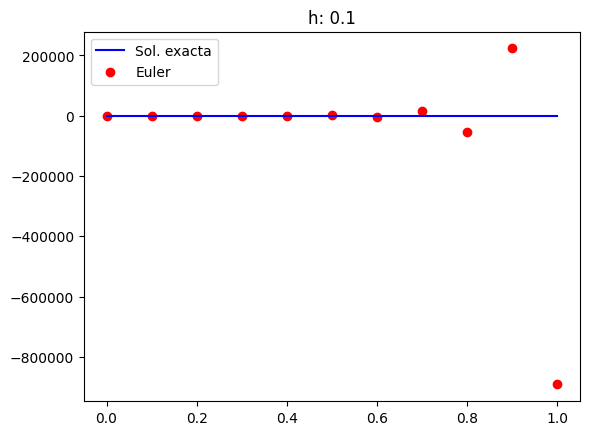

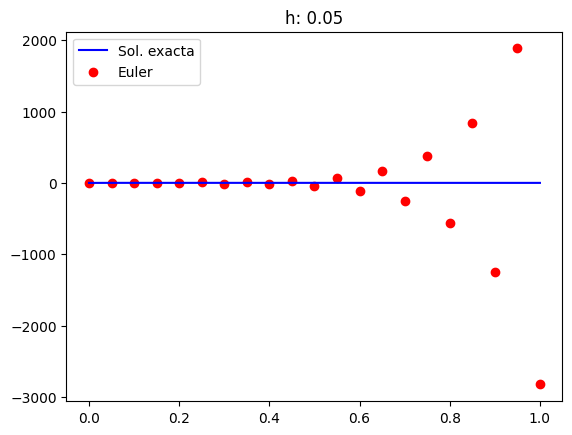

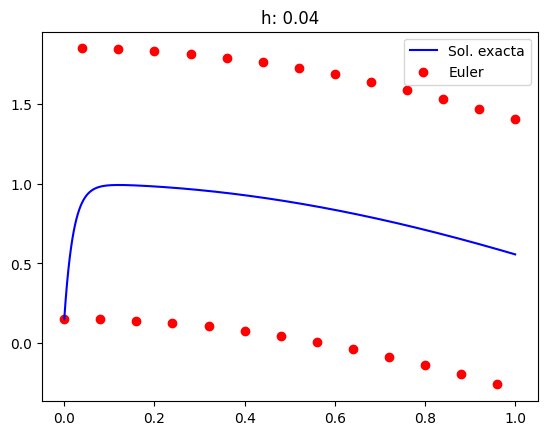

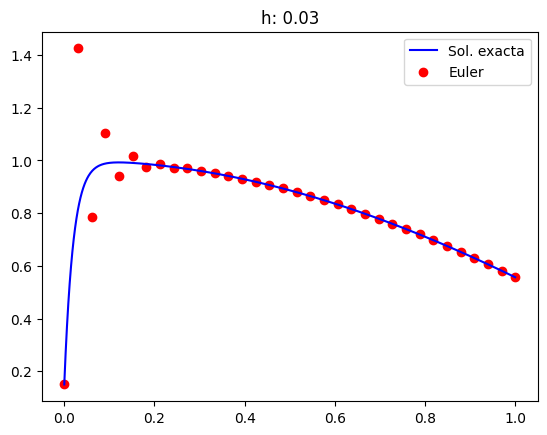

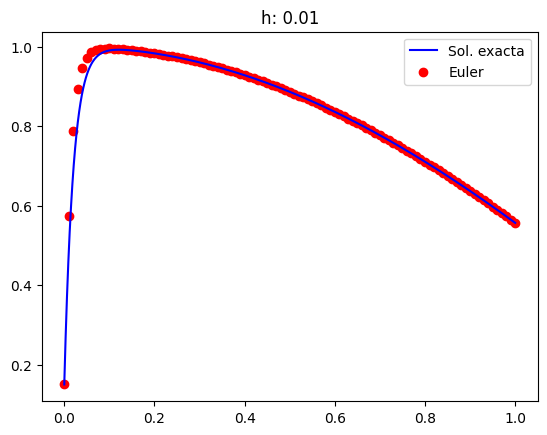

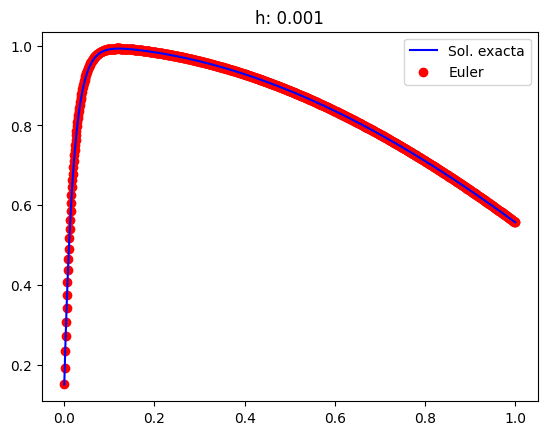

In [12]:
def y_exacta(t):
    return (2500/2501) * np.cos(t) + (50/2501) * np.sin(t) + (0.15 - 2500/2501) * np.exp(-50*t)

t_fino = np.linspace(0, 1, 1000)

for h in [0.1, 0.05, 0.04, 0.03, 0.01, 0.001]:
    t, y = euler(0.15, 0, 1, h)
    plt.plot(t_fino, y_exacta(t_fino), label='Sol. exacta', color='blue')
    plt.scatter(t, y, label='Euler', color='red')
    plt.legend()
    plt.title(f'h: {h}')
    plt.show()

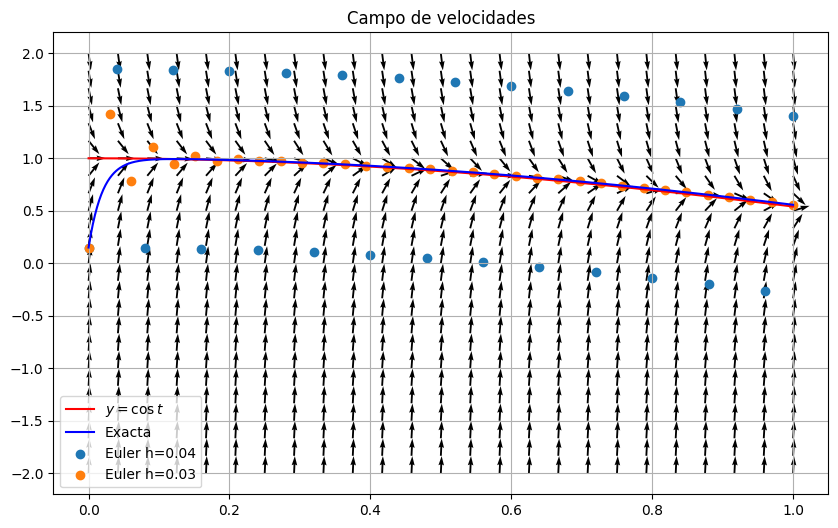

In [25]:
# Campo de velocidades

def f(t, y): 
    return -50 * (y - np.cos(t))

t_valores = np.linspace(0, 1, 25)
y_valores = np.linspace(-2, 2, 25)

T, Y, = np.meshgrid(t_valores, y_valores)

U = np.ones_like(T)
V = f(T, Y)

norma = np.sqrt(U**2 + V**2)
U_norm = U / norma
V_norm = V / norma

plt.figure(figsize=(10, 6))
plt.quiver(T, Y, U_norm, V_norm, angles='xy')

plt.plot(t_fino, np.cos(t_fino), 'r', label=r'$y=\cos t$')

# Solucion exacta
t_fino = np.linspace(0, 1, 1000)
plt.plot(t_fino, y_exacta(t_fino), label='Exacta', color='blue')

# Euler con h = 0.04
t1, y1 = euler(0.15, 0, 1, 0.04)
plt.scatter(t1, y1, label='Euler h=0.04')

# Euler con h = 0.03
t2, y2 = euler(0.15, 0, 1, 0.03)
plt.scatter(t2, y2, label='Euler h=0.03')

plt.title('Campo de velocidades')
plt.grid(True)
plt.legend()
plt.show()

Al superponer las aproximaciones de Euler sobre el campo de velocidades, se observa que la solución exacta sigue la dirección indicada por el campo y se mantiene cercana a la curva \(y=\cos t\), que es donde la pendiente se anula. La aproximación de Euler con \(h=0.03\) reproduce mejor este comportamiento que la obtenida con \(h=0.04\). Esto muestra que, para esta ecuación, el método de Euler necesita pasos suficientemente pequeños para capturar correctamente la dinámica rápida impuesta por el factor \(50\).